# **Water Quality Data Analysis**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\DA2_Assessment\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\DA2_Assessment'

# Section 1

Section 1 content

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("data/Raw_data/heart.csv")
df.head(20)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [7]:
list(df.columns)

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [8]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


(918, 12)

In [19]:
df.duplicated().sum()

0

In [14]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


---

# Section 2: Transform

**Missing Values Analysis**

In [13]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

**Outlier Detection**

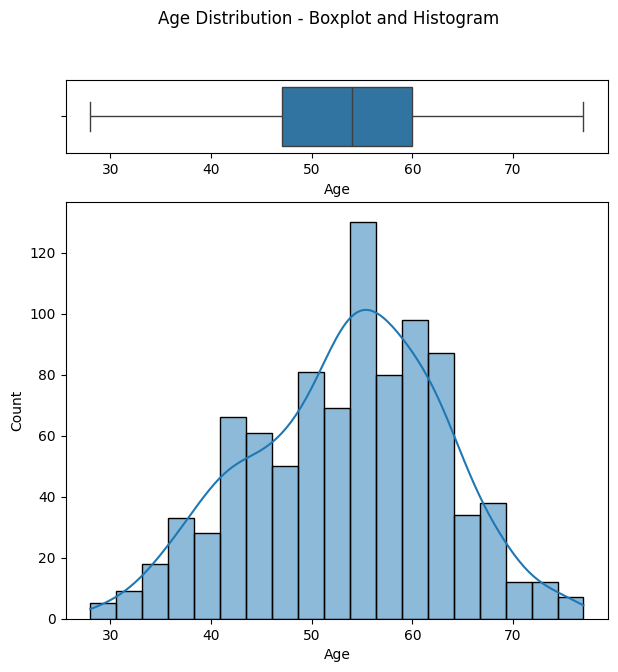

This is the range where a data point is not an outlier: from 27.5 to 79.5




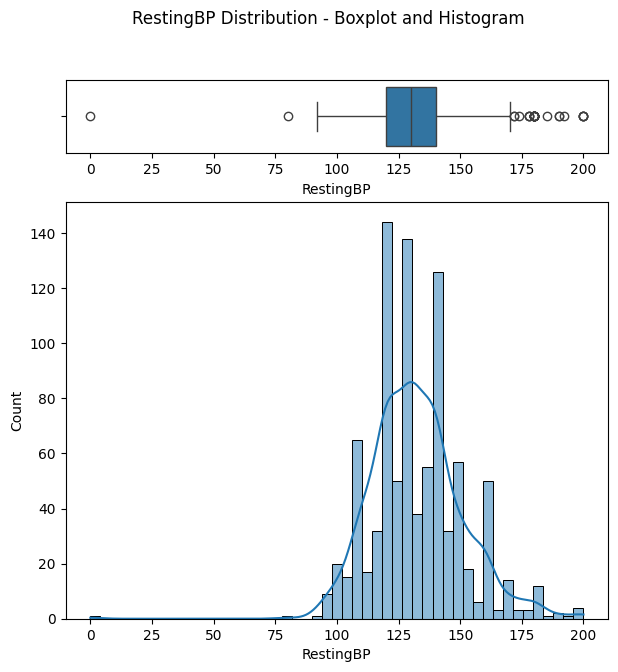

This is the range where a data point is not an outlier: from 90.0 to 170.0




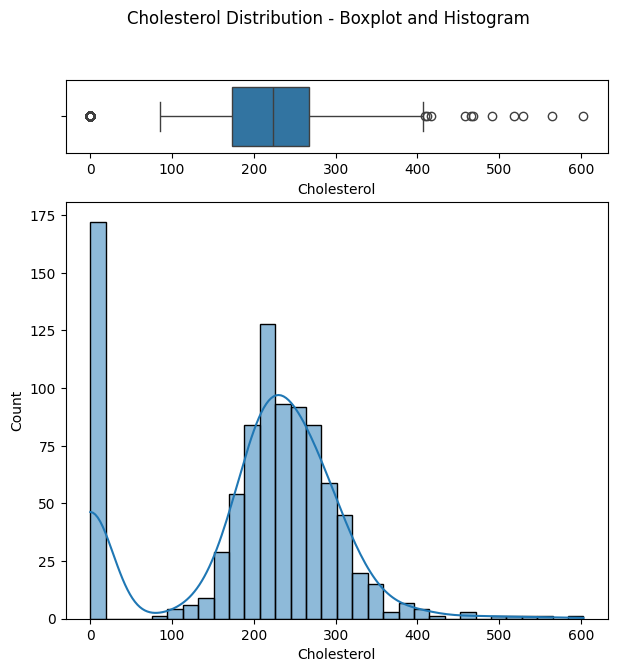

This is the range where a data point is not an outlier: from 32.62 to 407.62




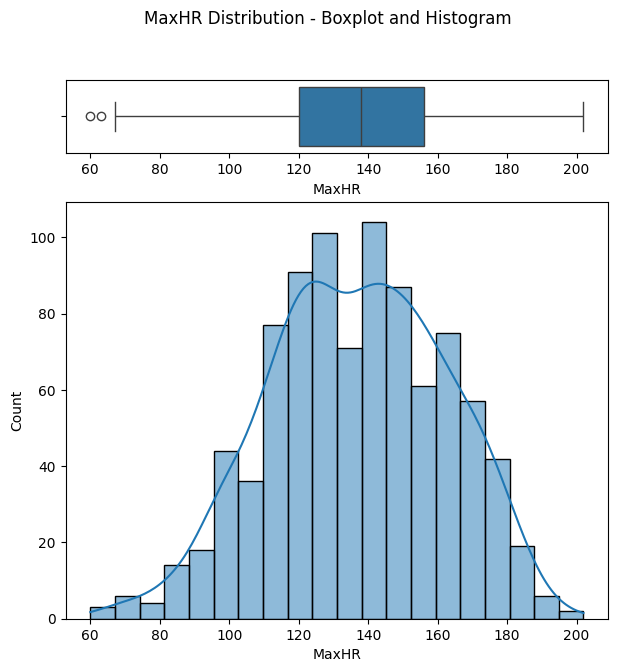

This is the range where a data point is not an outlier: from 66.0 to 210.0




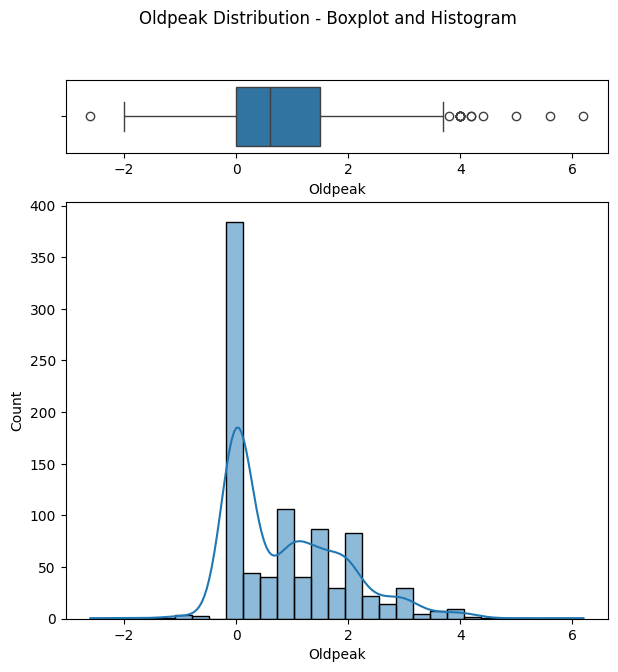

This is the range where a data point is not an outlier: from -2.25 to 3.75




In [20]:
def plot_histogram_and_boxplot(df):
    selected_cols = ['Age','RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
    
    for col in selected_cols:
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), gridspec_kw={"height_ratios": (.15, .85)})
        sns.boxplot(data=df, x=col, ax=axes[0])
        sns.histplot(data=df, x=col, kde=True, ax=axes[1])
        fig.suptitle(f"{col} Distribution - Boxplot and Histogram")
        plt.show()

        # Only calculate IQR for numeric columns
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = (Q1 - 1.5 * IQR).round(2)
            upper = (Q3 + 1.5 * IQR).round(2)
            print(f"This is the range where a data point is not an outlier: from {lower} to {upper}")
            print("\n")
plot_histogram_and_boxplot(df)

In [33]:
df_corr=df[['RestingBP', 'Cholesterol', 'Age', 'MaxHR', 'HeartDisease','FastingBS','Oldpeak']].corr(method='pearson')
df_corr

,RestingBP,Cholesterol,Age,MaxHR,HeartDisease,FastingBS,Oldpeak
RestingBP,1.000000,0.100893,0.254399,-0.112135,0.107589,0.070193,0.164803
Cholesterol,0.100893,1.000000,-0.095282,0.235792,-0.232741,-0.260974,0.050148
Age,0.254399,-0.095282,1.000000,-0.382045,0.282039,0.198039,0.258612
MaxHR,-0.112135,0.235792,-0.382045,1.000000,-0.400421,-0.131438,-0.160691
HeartDisease,0.107589,-0.232741,0.282039,-0.400421,1.000000,0.267291,0.403951
FastingBS,0.070193,-0.260974,0.198039,-0.131438,0.267291,1.000000,0.052698
Oldpeak,0.164803,0.050148,0.258612,-0.160691,0.403951,0.052698,1.000000


**Winsorizer - Capping Outliers**

---

In [33]:
from feature_engine.outliers import Winsorizer
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('winsorizer_iqr', Winsorizer(capping_method = 'iqr', fold=1.5, tail='both', variables = ['ph', 'Hardness','Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes']))
])
df_transformed = pipeline.fit_transform(df)
df_transformed.head(8)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.889107,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


In [34]:
pipeline['winsorizer_iqr'].right_tail_caps_

{'ph': 10.258615434291345,
 'Hardness': 276.3928337208903,
 'Solids': 44831.86987314956,
 'Chloramines': 11.09608644703562,
 'Sulfate': 400.3224341668413,
 'Conductivity': 655.8791400416264,
 'Organic_carbon': 23.295426859188986,
 'Trihalomethanes': 106.69503986064285}

In [35]:
pipeline['winsorizer_iqr'].left_tail_caps_

{'ph': 3.889106956840228,
 'Hardness': 117.12516037150485,
 'Solids': -1832.4174487462951,
 'Chloramines': 3.1462213405647073,
 'Sulfate': 267.15795986167404,
 'Conductivity': 191.64757856456453,
 'Organic_carbon': 5.328026018267515,
 'Trihalomethanes': 26.619225158022296}

========Before Outlier Treatment========


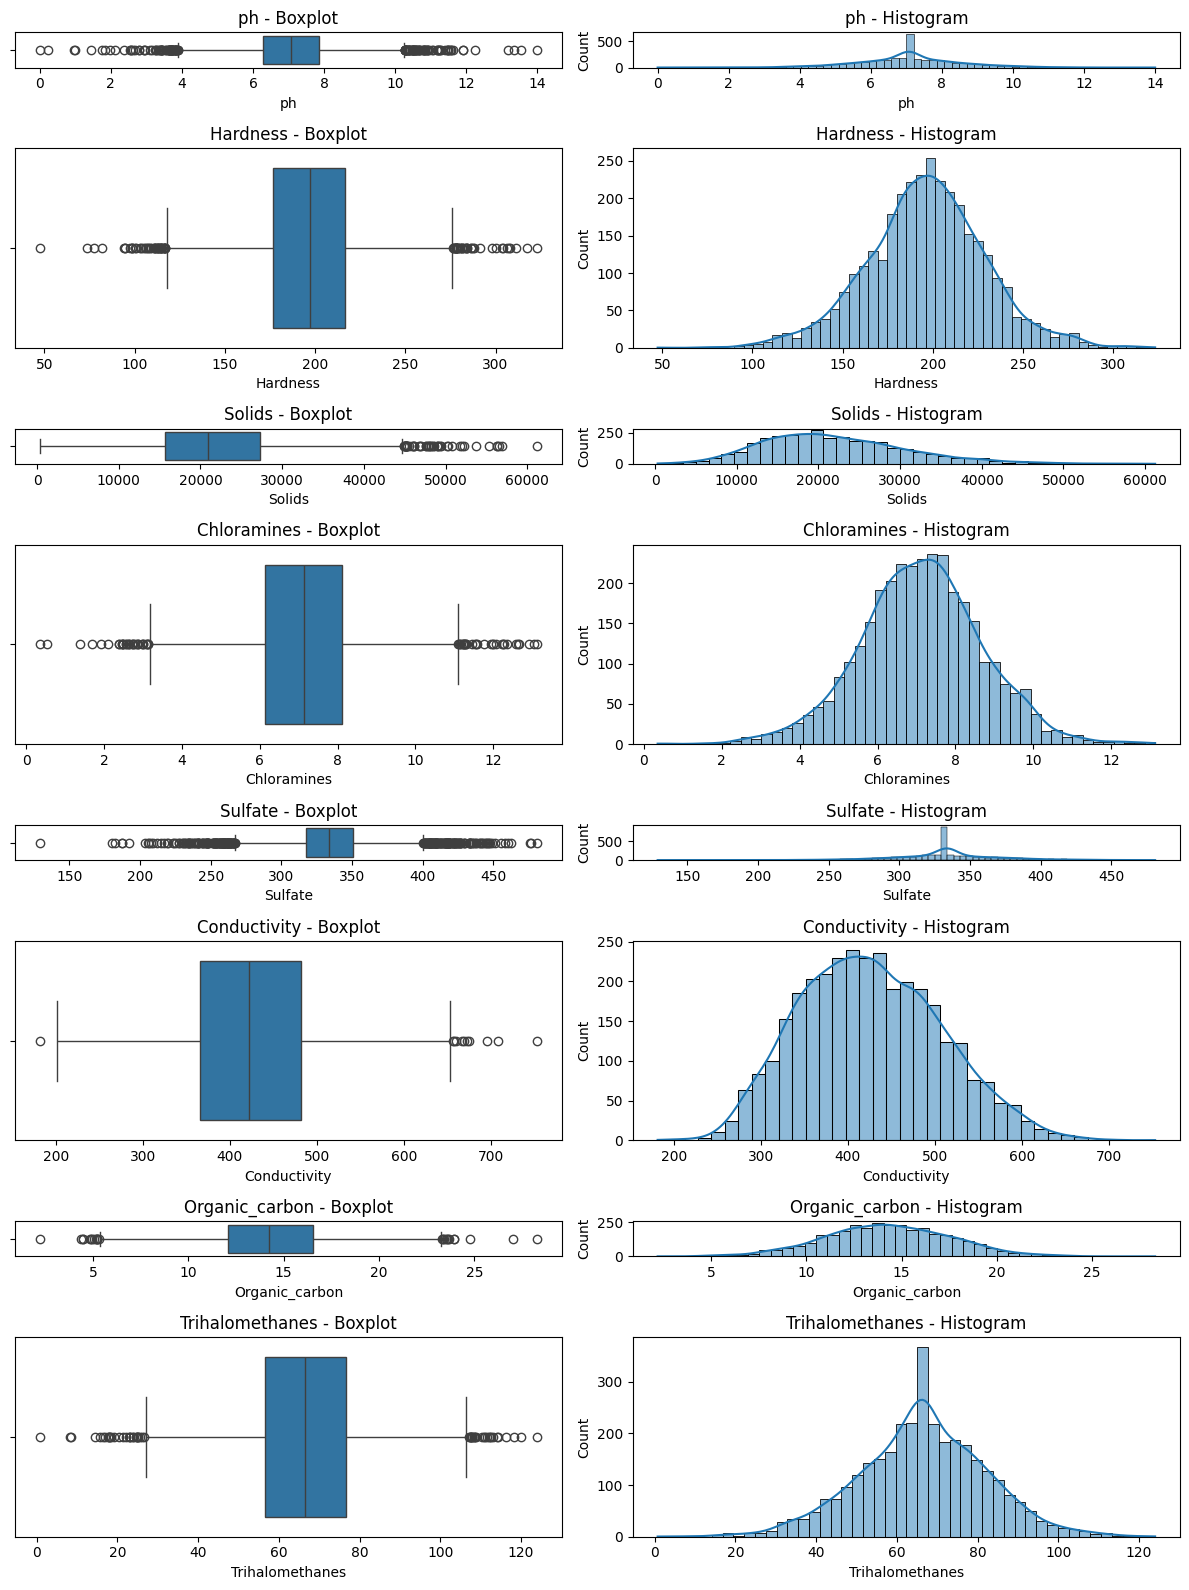

========After Outlier Treatment========


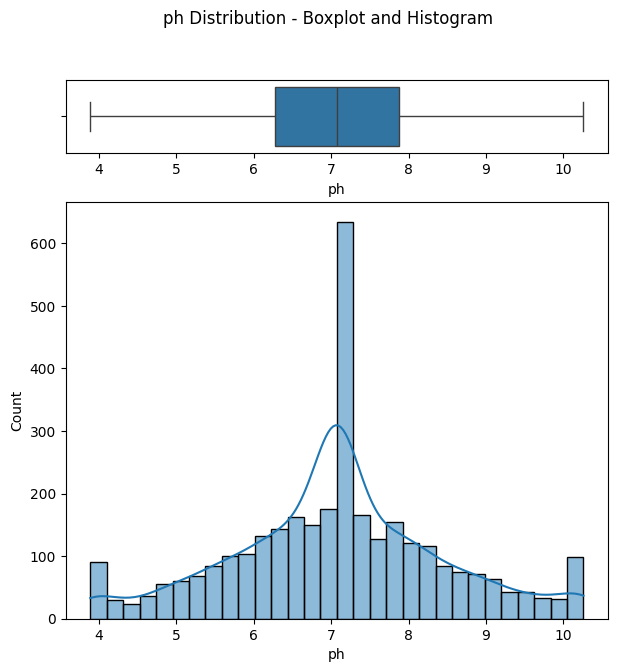

This is the range where a data point is not an outlier: from 3.89 to 10.26




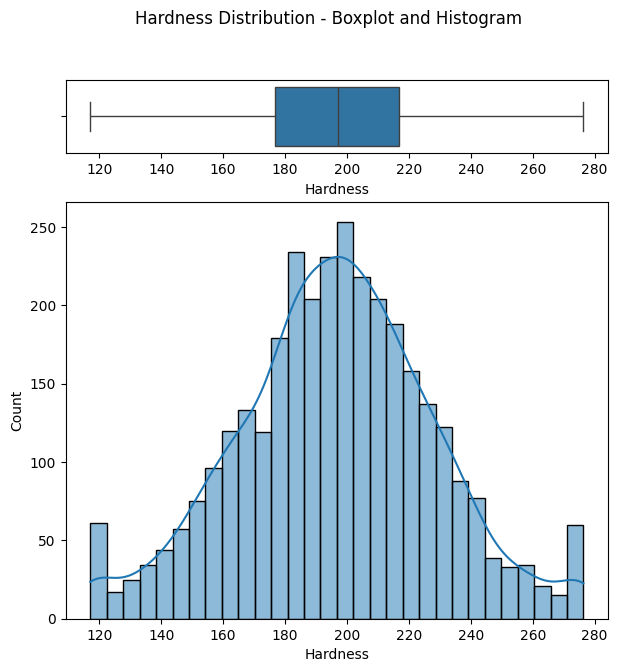

This is the range where a data point is not an outlier: from 117.13 to 276.39




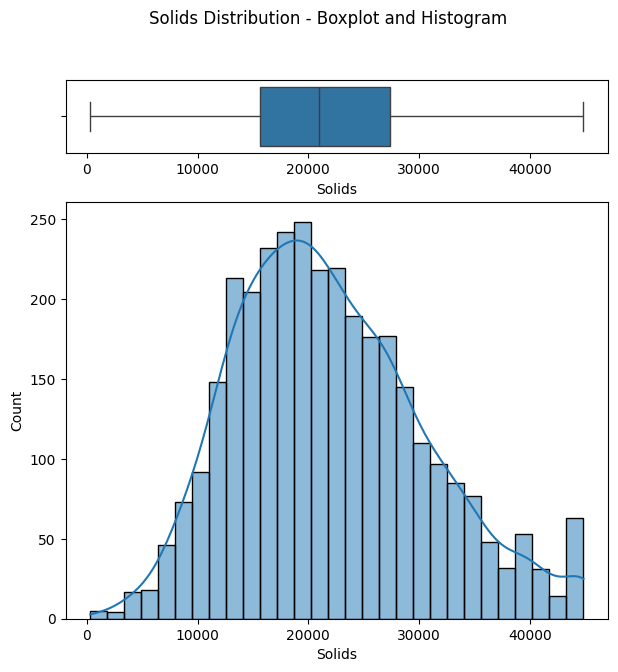

This is the range where a data point is not an outlier: from -1832.42 to 44831.87




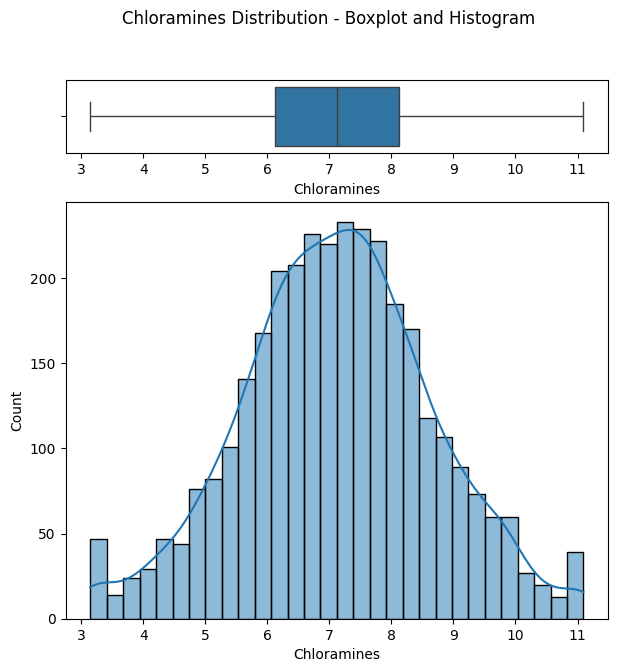

This is the range where a data point is not an outlier: from 3.15 to 11.1




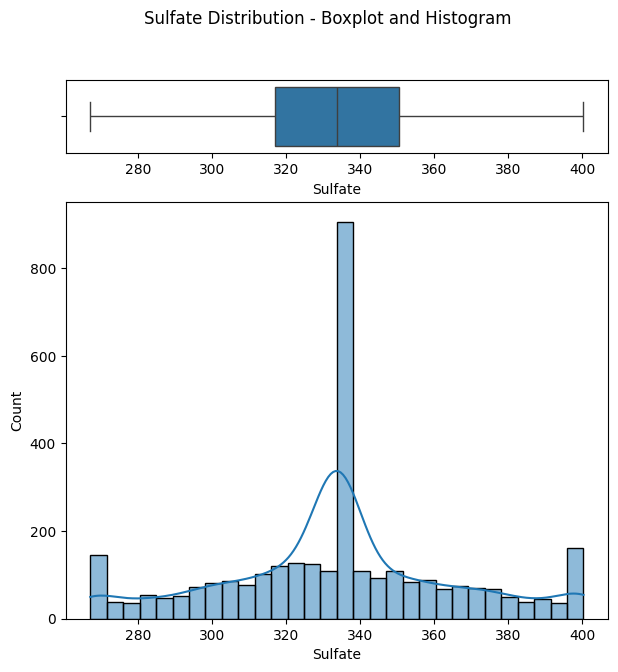

This is the range where a data point is not an outlier: from 267.16 to 400.32




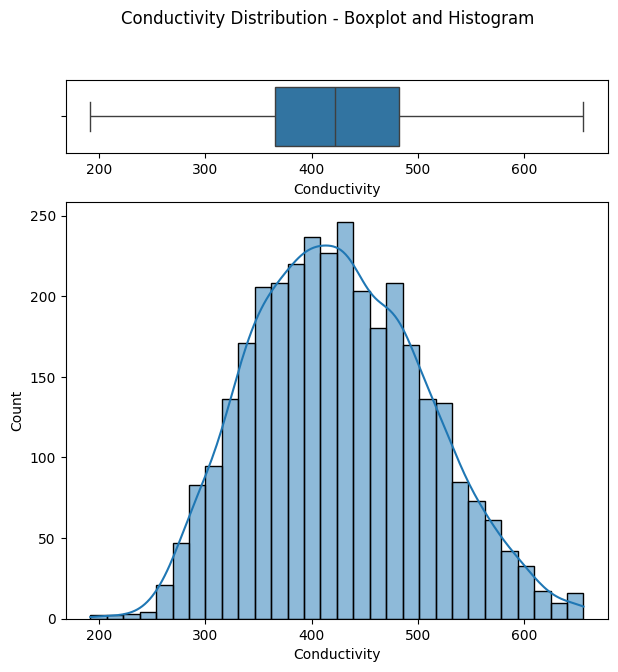

This is the range where a data point is not an outlier: from 191.65 to 655.88




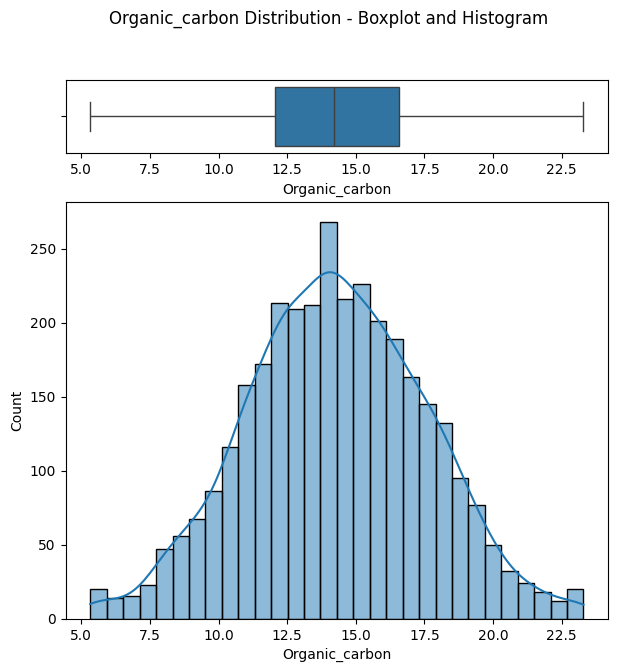

This is the range where a data point is not an outlier: from 5.33 to 23.3




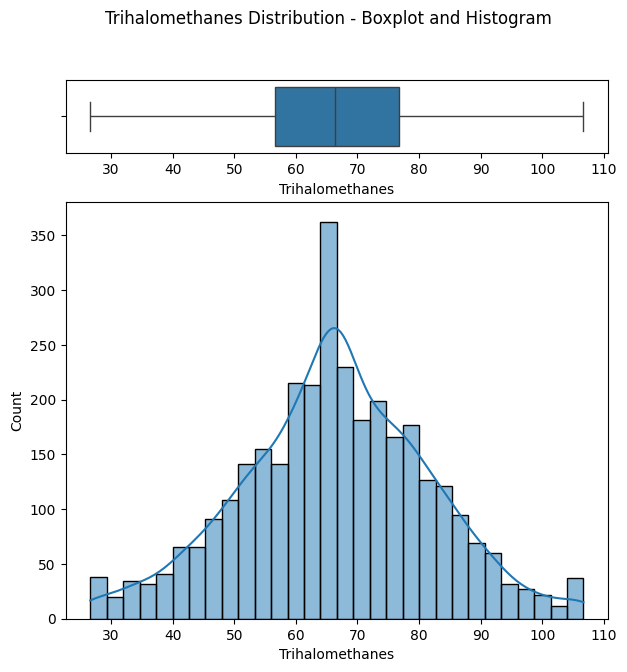

This is the range where a data point is not an outlier: from 26.62 to 106.7




In [45]:
print("========Before Outlier Treatment========")
selected_cols = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes']
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(12, 16), gridspec_kw={"height_ratios": [.15, .85] * 4})

for idx, col in enumerate(selected_cols):
	box_ax = axes[idx, 0]
	hist_ax = axes[idx, 1]
	sns.boxplot(data=df, x=col, ax=box_ax)
	sns.histplot(data=df, x=col, kde=True, ax=hist_ax)
	box_ax.set_title(f"{col} - Boxplot")
	hist_ax.set_title(f"{col} - Histogram")

plt.tight_layout()
plt.show()


print("========After Outlier Treatment========")
plot_histogram_and_boxplot(df_transformed)

In [38]:
df_transformed.describe()   

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.079949,196.392423,21957.112200,7.121794,333.788678,426.129974,14.283462,66.420427,3.966786,0.390110
std,1.381951,32.017189,8592.820397,1.544126,31.768004,80.564144,3.288367,15.487146,0.780382,0.487849
min,3.889107,117.125160,320.942611,3.146221,267.157960,191.647579,5.328026,26.619225,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.080795,196.967627,20927.833607,7.130299,333.775777,421.884968,14.218338,66.396293,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,10.258615,276.392834,44831.869873,11.096086,400.322434,655.879140,23.295427,106.695040,6.739000,1.000000


In [40]:
df_transformed.to_csv('Cleaned_Date.csv')

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.